# Battery Materials DSS QML

**Presentation notebook**

Goal: build a student-level Decision Support System for lithium-ion battery
material recommendation using Materials Project data, India-focused screening,
XGBoost, and simulated QML comparison.


## Student-Level Project Flow

This project is presented as a DSS first and a QML exploration second.

1. XGBoost is the strong current classical benchmark for structured materials
   data.
2. Logistic Regression is the simple classical baseline.
3. Simulated QML is the quantum-future experiment.
4. The final recommendation is made through DSS ranking tables, not through an
   unsupported claim of quantum advantage.

**Why quantum is included**

Battery materials are controlled by atomic and electronic behavior. That
behavior is quantum mechanical. Classical ML is useful today, but future
quantum models may represent material interactions more naturally. This project
therefore uses simulated QML as a safe first step toward quantum-assisted
materials discovery.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scripts.notebook_data_loader import load_presentation_data

(
    lithium_scored_dataframe,
    final_shortlist_dataframe,
    dss_family_ranking_dataframe,
    dss_compound_ranking_dataframe,
    dss_material_ranking_dataframe,
    qml_ready_dataframe,
    qml_predictions_dataframe,
    tuned_qml_predictions_dataframe,
    qml_exhaustive_results_dataframe,
    qml_exhaustive_top_results_dataframe,
    qml_exhaustive_best_result,
    improved_qml_dataset_dataframe,
    improved_qml_tuning_results_dataframe,
    improved_qml_predictions_dataframe,
    improved_qml_threshold_results_dataframe,
    improved_qml_threshold_predictions_dataframe,
    improved_qml_alignment_scores_dataframe,
    improved_qml_alignment_results_dataframe,
    improved_qml_alignment_predictions_dataframe,
    best_qml_repeated_split_results_dataframe,
    best_qml_repeated_split_predictions_dataframe,
    qml_vs_logistic_results_dataframe,
    qml_vs_logistic_summary_dataframe,
    qml_vs_logistic_predictions_dataframe,
    dataset_summary,
) = load_presentation_data(Path.cwd())

processed_folder = Path.cwd() / "data" / "processed"
display(dataset_summary)

dataset,rows,columns
Lithium India scored,24957,37
Final India shortlist,629,21
DSS compound ranking,629,22
DSS family context,6,16
QML-ready dataset,1000,27
QML test predictions,200,11
Tuned QML test predictions,200,8
Exhaustive QML tuning results,8388,12
Exhaustive QML top results,20,12
Improved QML PCA dataset,1000,14


stage,rows
Raw MP snapshot,210579
Lithium dataset,24957
QML-ready dataset,1000
Final shortlist,629


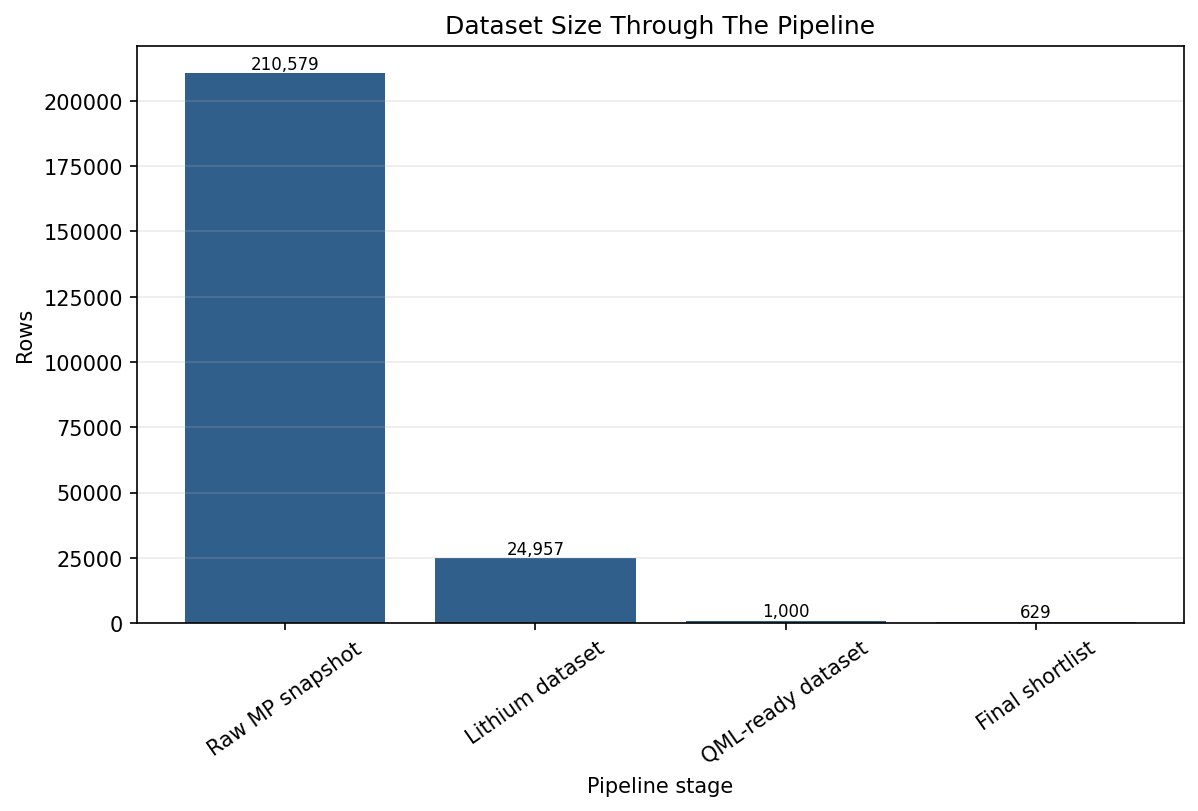

In [2]:
pipeline_counts_dataframe = pd.DataFrame([
    {"stage": "Raw MP snapshot", "rows": 210579},
    {"stage": "Lithium dataset", "rows": len(lithium_scored_dataframe)},
    {"stage": "QML-ready dataset", "rows": len(qml_ready_dataframe)},
    {"stage": "Final shortlist", "rows": len(final_shortlist_dataframe)},
])

plt.figure(figsize=(9, 5))
plt.bar(pipeline_counts_dataframe["stage"], pipeline_counts_dataframe["rows"])
plt.title("Dataset Size Through The Pipeline")
plt.xlabel("Pipeline stage")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

battery_family,rows
Other lithium material,14027
LCO-family,3541
LMO-family,3394
LTO-family,964
Li-S or sulfide-family,892
Silicon-family,852
LFP-family,735
Carbon-family,477


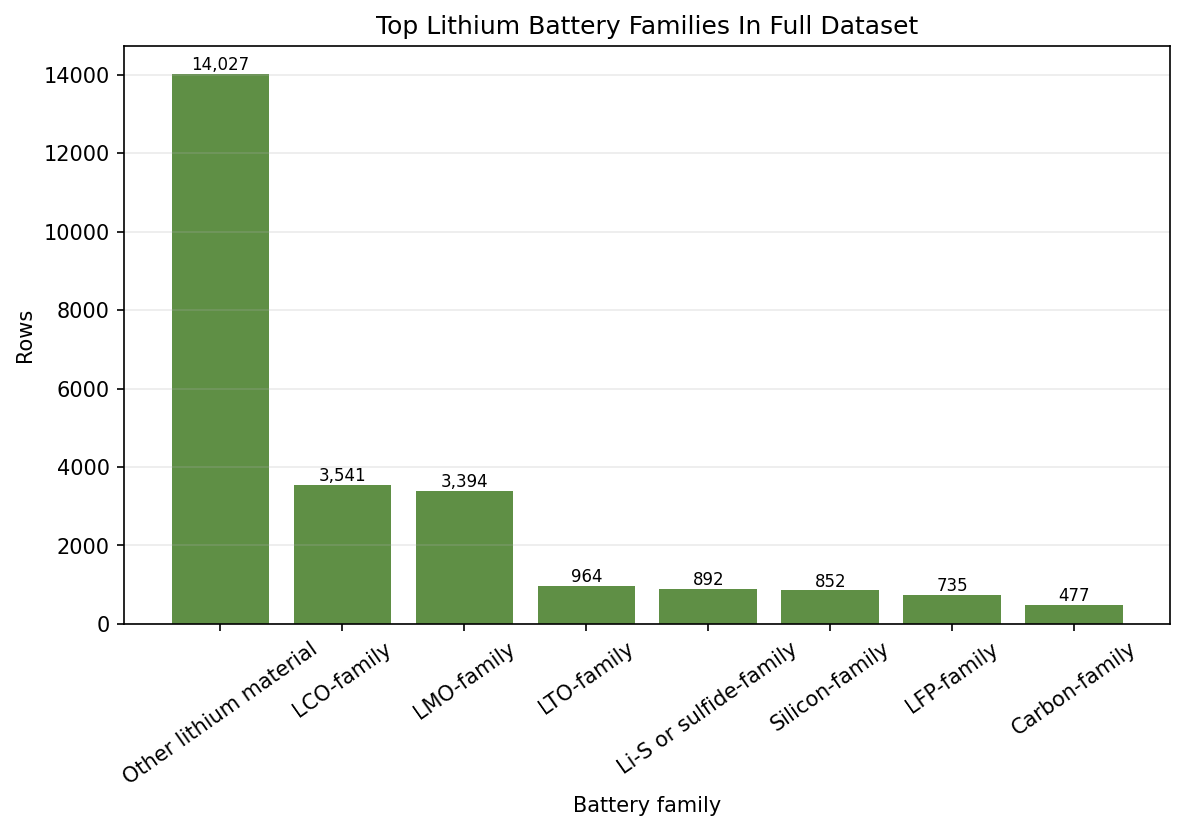

In [3]:
family_counts_dataframe = (
    lithium_scored_dataframe["battery_family"]
    .value_counts()
    .head(8)
    .reset_index()
)
family_counts_dataframe.columns = ["battery_family", "rows"]

display(family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(family_counts_dataframe["battery_family"], family_counts_dataframe["rows"])
plt.title("Top Lithium Battery Families In Full Dataset")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

india_decision_label,rows
Caution,13524
Research Candidate,5883
Avoid / Benchmark,4370
Recommend,1180


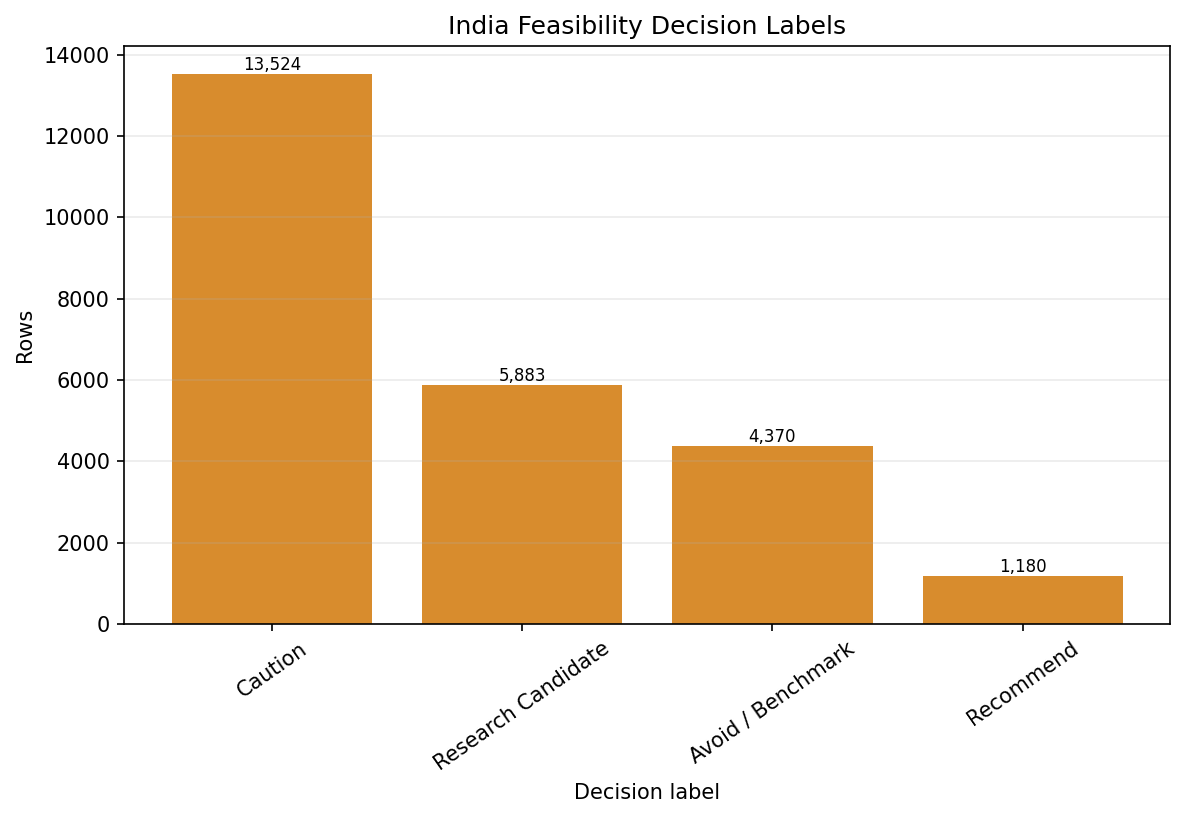

In [4]:
decision_counts_dataframe = (
    lithium_scored_dataframe["india_decision_label"]
    .value_counts()
    .reset_index()
)
decision_counts_dataframe.columns = ["india_decision_label", "rows"]

display(decision_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(decision_counts_dataframe["india_decision_label"], decision_counts_dataframe["rows"])
plt.title("India Feasibility Decision Labels")
plt.xlabel("Decision label")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

battery_family,rows
LFP-family,464
Li-S or sulfide-family,91
LMFP-family,48
Silicon-family,17
Carbon-family,5
LMO-family,4


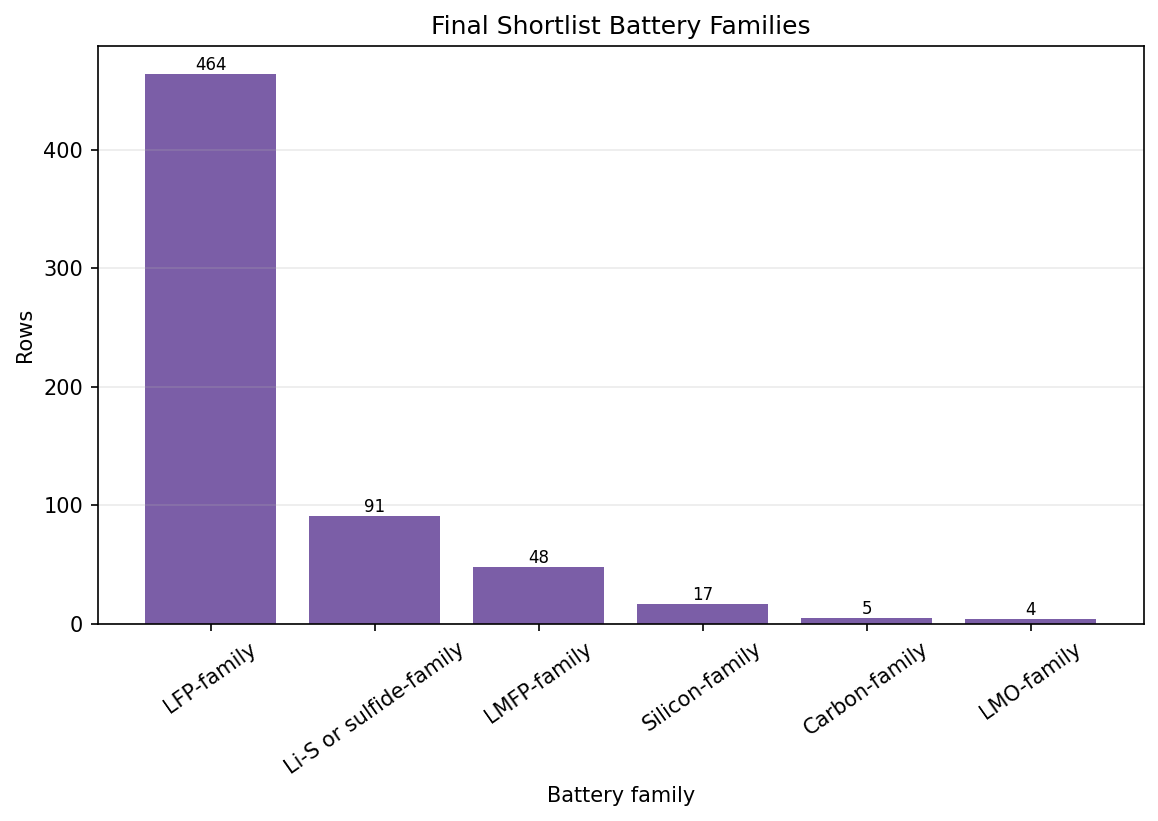

In [5]:
final_family_counts_dataframe = (
    final_shortlist_dataframe["battery_family"]
    .value_counts()
    .reset_index()
)
final_family_counts_dataframe.columns = ["battery_family", "rows"]

display(final_family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(final_family_counts_dataframe["battery_family"], final_family_counts_dataframe["rows"])
plt.title("Final Shortlist Battery Families")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

In [6]:
top_candidate_columns = [
    "material_id",
    "formula",
    "battery_family",
    "india_decision_label",
    "shortlist_rule_type",
    "shortlist_score",
    "predicted_stable_probability",
    "predicted_energy_above_hull_clipped",
    "india_feasibility_score",
]
top_candidates_dataframe = final_shortlist_dataframe[top_candidate_columns].head(10)
display(top_candidates_dataframe)

material_id,formula,battery_family,india_decision_label,shortlist_rule_type,shortlist_score,predicted_stable_probability,predicted_energy_above_hull_clipped,india_feasibility_score
mp-19430,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,59.52,0.167670,0.011649,98
mp-554093,Li9Fe3P8O29,LFP-family,Recommend,Benchmark family exception,59.10,0.147220,0.009104,98
mp-1195117,LiFeP2(HO3)2,LFP-family,Recommend,Benchmark family exception,57.42,0.172900,0.016302,94
mp-19294,LiFeP2O7,LFP-family,Recommend,Benchmark family exception,57.26,0.222164,0.038672,100
mp-19017,LiFePO4,LFP-family,Recommend,Benchmark family exception,56.48,0.138139,0.023703,100
mp-26985,Li2Fe3(P2O7)2,LFP-family,Recommend,Benchmark family exception,56.39,0.115441,0.015525,98
mp-1198378,NaLiFePO4F,LFP-family,Recommend,Benchmark family exception,56.22,0.167278,0.021042,94
mp-6373,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.50,0.131681,0.023631,98
mp-25993,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.32,0.126405,0.023346,98
mp-504179,LiFe(PO3)3,LFP-family,Recommend,Benchmark family exception,54.88,0.132133,0.026851,98


## DSS Compound Recommendation Ranking

The project is used as a Decision Support System here. The main output is a
ranked list of exact lithium compound formulas. Battery family is shown only as
supporting context.

In this flow, QML gives the first stability signal. XGBoost is used as a
corrective backup when the QML probability is uncertain or when both models
disagree. This keeps the DSS quantum-led without ignoring the stronger
classical benchmark.


In [7]:
dss_compound_display_columns = [
    "dss_rank",
    "formula",
    "material_id",
    "battery_family",
    "dss_decision",
    "hybrid_recommendation_score",
    "hybrid_stable_probability",
    "qml_stable_probability",
    "xgboost_stable_probability",
    "qml_confidence_band",
    "hybrid_decision_role",
    "model_disagreement",
    "shortlist_score",
    "india_feasibility_score",
    "predicted_energy_above_hull_clipped",
    "band_gap",
    "short_conceptual_reason",
]
dss_compound_display_dataframe = dss_compound_ranking_dataframe[
    dss_compound_display_columns
].head(10)
display(dss_compound_display_dataframe)

dss_family_display_columns = [
    "dss_rank",
    "battery_family",
    "dss_decision",
    "shortlist_rows",
    "average_hybrid_recommendation_score",
    "average_hybrid_stable_probability",
    "average_qml_stable_probability",
    "average_xgboost_stable_probability",
    "average_india_feasibility_score",
    "median_predicted_energy_above_hull",
    "top_formula",
    "short_reason",
]
dss_family_display_dataframe = dss_family_ranking_dataframe[dss_family_display_columns]
display(dss_family_display_dataframe)

dss_rank,formula,material_id,battery_family,dss_decision,hybrid_recommendation_score,hybrid_stable_probability,qml_stable_probability,xgboost_stable_probability,qml_confidence_band,hybrid_decision_role,model_disagreement,shortlist_score,india_feasibility_score,predicted_energy_above_hull_clipped,band_gap,short_conceptual_reason
1,SrLi2SiO4,mp-1191141,Silicon-family,R&D anode improvement option,88.4616,0.840090,0.850246,0.825156,QML confident stable,QML-led; XGBoost agrees,False,87.58,87,0.000000,4.6041,High-potential anode direction; better for blended or future designs. India score 87; QML probability 0.8502; XGBoost probability 0.8252; hybrid probability 0.8401; predicted hull 0.0000.
2,Li2MnGeS4,mp-3268644,Li-S or sulfide-family,Long-term R&D option,87.7709,0.869018,0.845344,0.903325,QML confident stable,QML-led; XGBoost agrees,False,88.83,81,0.000864,1.9728,"High-potential chemistry, but less direct for immediate purchase. India score 81; QML probability 0.8453; XGBoost probability 0.9033; hybrid probability 0.8690; predicted hull 0.0009."
3,LiGaSiO4,mp-18147,Silicon-family,R&D anode improvement option,87.5647,0.832933,0.851558,0.805444,QML confident stable,QML-led; XGBoost agrees,False,86.22,87,0.002373,4.2293,High-potential anode direction; better for blended or future designs. India score 87; QML probability 0.8516; XGBoost probability 0.8054; hybrid probability 0.8329; predicted hull 0.0024.
4,SrLi2SnS4,mp-3210567,Li-S or sulfide-family,Long-term R&D option,87.2890,0.878225,0.867029,0.895510,QML confident stable,QML-led; XGBoost agrees,False,87.60,78,0.000000,3.0972,"High-potential chemistry, but less direct for immediate purchase. India score 78; QML probability 0.8670; XGBoost probability 0.8955; hybrid probability 0.8782; predicted hull 0.0000."
5,Rb2Li2SnS4,mp-3205208,Li-S or sulfide-family,Long-term R&D option,87.2332,0.875854,0.856946,0.904204,QML confident stable,QML-led; XGBoost agrees,False,87.99,78,0.000000,3.0399,"High-potential chemistry, but less direct for immediate purchase. India score 78; QML probability 0.8569; XGBoost probability 0.9042; hybrid probability 0.8759; predicted hull 0.0000."
6,Cs2Li2SnS4,mp-3209528,Li-S or sulfide-family,Long-term R&D option,87.2222,0.875530,0.856042,0.904665,QML confident stable,QML-led; XGBoost agrees,False,88.01,78,0.000000,3.2409,"High-potential chemistry, but less direct for immediate purchase. India score 78; QML probability 0.8560; XGBoost probability 0.9047; hybrid probability 0.8755; predicted hull 0.0000."
7,BaLi2SnS4,mp-3211122,Li-S or sulfide-family,Long-term R&D option,87.1720,0.875950,0.866990,0.889782,QML confident stable,QML-led; XGBoost agrees,False,87.34,78,0.000000,3.0828,"High-potential chemistry, but less direct for immediate purchase. India score 78; QML probability 0.8670; XGBoost probability 0.8898; hybrid probability 0.8760; predicted hull 0.0000."
8,Li2ZnGeS4,mp-1210804,Li-S or sulfide-family,Long-term R&D option,86.7154,0.863859,0.841666,0.895690,QML confident stable,QML-led; XGBoost agrees,False,87.61,78,0.000000,2.1846,"High-potential chemistry, but less direct for immediate purchase. India score 78; QML probability 0.8417; XGBoost probability 0.8957; hybrid probability 0.8639; predicted hull 0.0000."
9,Rb2Li2TiS4,mp-3215312,Li-S or sulfide-family,Long-term R&D option,86.5092,0.850330,0.869000,0.821337,QML confident stable,QML-led; XGBoost agrees,False,84.96,80,0.000000,2.6367,"High-potential chemistry, but less direct for immediate purchase. India score 80; QML probability 0.8690; XGBoost probability 0.8213; hybrid probability 0.8503; predicted hull 0.0000."
10,K2Li2TiS4,mp-3205916,Li-S or sulfide-family,Long-term R&D option,86.5061,0.850327,0.869383,0.820697,QML confident stable,QML-led; XGBoost agrees,False,84.93,80,0.000000,2.5669,"High-potential chemistry, but less direct for immediate purchase. India score 80; QML probability 0.8694; XGBoost probability 0.8207; hybrid probability 0.8503; predicted hull 0.0000."


dss_rank,battery_family,dss_decision,shortlist_rows,average_hybrid_recommendation_score,average_hybrid_stable_probability,average_qml_stable_probability,average_xgboost_stable_probability,average_india_feasibility_score,median_predicted_energy_above_hull,top_formula,short_reason
1,Silicon-family,R&D anode improvement option,17,83.1593,0.8004,0.8436,0.7376,87.0000,0.0151,SrLi2SiO4,High-potential anode direction; better for blended or future designs.
2,Li-S or sulfide-family,Long-term R&D option,91,81.8842,0.8022,0.8037,0.7928,78.0220,0.0034,Li2MnGeS4,"High-potential chemistry, but less direct for immediate purchase."
3,LMO-family,Selective low-cost option,4,77.7268,0.7567,0.8153,0.6783,89.2500,0.0288,Li2MgMn3O8,"Manganese-based family; useful when cost matters, but needs checks."
4,Carbon-family,Useful anode/support material,5,70.6455,0.7201,0.7128,0.7261,94.8000,0.0647,LiEr4MnC8,"Practical supporting material, but not a complete battery-cell choice."
5,LFP-family,Best near-term purchase direction,464,48.3320,0.1033,0.1626,0.0148,96.0259,0.0487,Li9Fe3P8O29,India-friendly iron phosphate chemistry; avoids nickel and cobalt.
6,LMFP-family,Good pilot and next-generation option,48,48.0997,0.0894,0.1428,0.0094,94.2083,0.0398,Na4Li4MnFe3P4(O4F)4,LFP-like family with manganese; useful for improving performance.


In [8]:
quantum_parameters_dataframe = pd.DataFrame([
    {"parameter": "QML model type", "value": "Simulated quantum kernel classifier"},
    {"parameter": "Student-level role", "value": "Quantum-future experiment, not a full replacement for XGBoost"},
    {"parameter": "Why quantum is relevant", "value": "Battery materials are quantum systems at atomic scale"},
    {"parameter": "Original number of qubits", "value": "10"},
    {"parameter": "Tuned number of qubits", "value": "8"},
    {"parameter": "Tuned quantum state size", "value": "256"},
    {"parameter": "Original feature encoding", "value": "angle = pi * scaled_feature_value"},
    {"parameter": "Tuned feature encoding", "value": "angle = (pi / 2) * scaled_feature_value"},
    {"parameter": "Single-qubit state", "value": "[cos(angle / 2), sin(angle / 2)]"},
    {"parameter": "Kernel formula", "value": "K(x, y) = |<phi(x), phi(y)>|^2"},
    {"parameter": "Classifier", "value": "SVC with precomputed kernel"},
    {"parameter": "Tuned SVM C value", "value": "1.0"},
    {"parameter": "Tuning method", "value": "4-fold cross-validation"},
    {"parameter": "Improved separate section", "value": "Random Forest feature importance + PCA + kernel tuning"},
    {"parameter": "Improved best qubits", "value": "6"},
    {"parameter": "Improved best kernel", "value": "entangled_pi"},
    {"parameter": "Improved best angle scale", "value": "pi"},
    {"parameter": "Improved best SVM C value", "value": "2.0"},
    {"parameter": "Threshold experiment", "value": "Stable-probability cutoff tuned by cross-validation"},
    {"parameter": "Best stable threshold", "value": "0.50"},
    {"parameter": "Kernel alignment experiment", "value": "Feature set selected by quantum kernel-target alignment"},
    {"parameter": "Alignment best feature set", "value": "rf_top_4"},
    {"parameter": "Alignment best qubits", "value": "4"},
    {"parameter": "Alignment best kernel", "value": "entangled_pi"},
    {"parameter": "Alignment best SVM C value", "value": "5.0"},
    {"parameter": "Train/test split", "value": "80/20"},
    {"parameter": "Random state", "value": "42"},
])
display(quantum_parameters_dataframe)

parameter,value
QML model type,Simulated quantum kernel classifier
Original number of qubits,10
Tuned number of qubits,8
Tuned quantum state size,256
Original feature encoding,angle = pi * scaled_feature_value
Tuned feature encoding,angle = (pi / 2) * scaled_feature_value
Single-qubit state,"[cos(angle / 2), sin(angle / 2)]"
Kernel formula,"K(x, y) = |<phi(x), phi(y)>|^2"
Classifier,SVC with precomputed kernel
Tuned SVM C value,1.0


qubit,feature,gate,angle
q0,formation_energy_per_atom,RY(theta_0),theta_0 = pi * scaled formation_energy_per_atom
q1,has_o,RY(theta_1),theta_1 = pi * scaled has_o
q2,space_group_number,RY(theta_2),theta_2 = pi * scaled space_group_number
q3,theoretical,RY(theta_3),theta_3 = pi * scaled theoretical


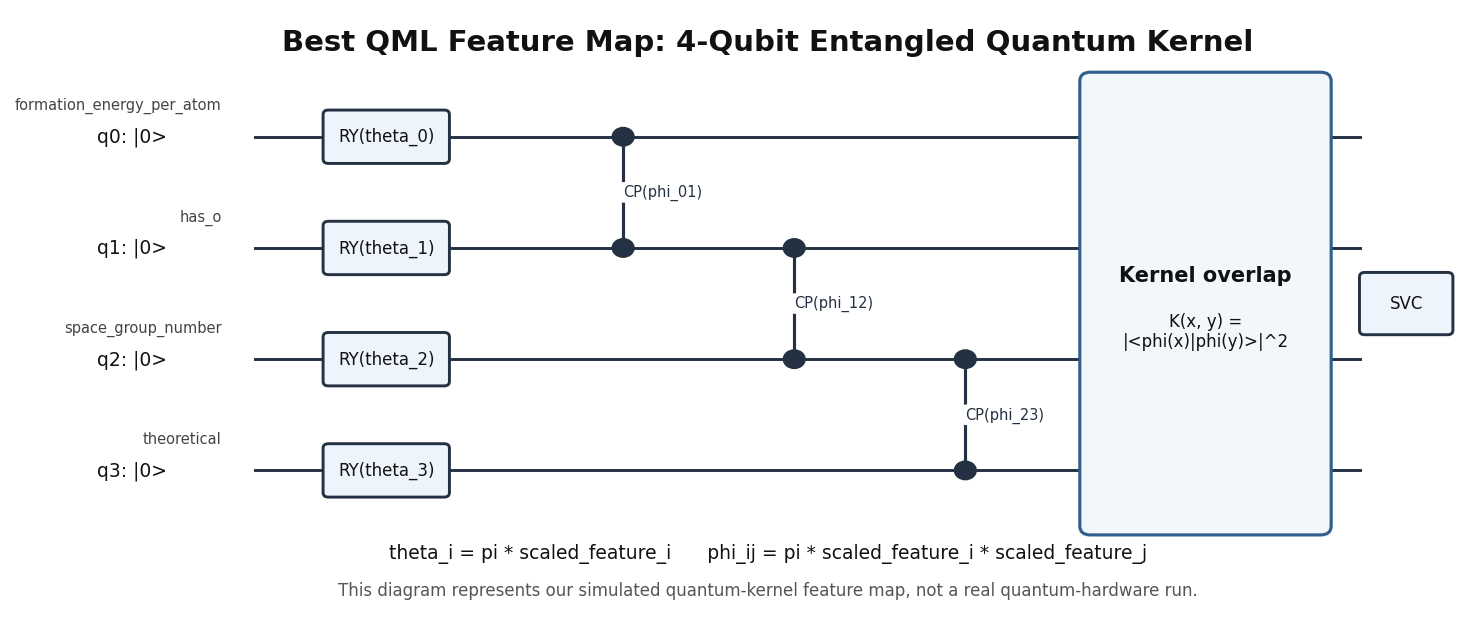

In [9]:
qml_circuit_dataframe = pd.DataFrame([
    {
        "qubit": "q0",
        "feature": "formation_energy_per_atom",
        "gate": "RY(theta_0)",
        "angle": "theta_0 = pi * scaled formation_energy_per_atom",
    },
    {
        "qubit": "q1",
        "feature": "has_o",
        "gate": "RY(theta_1)",
        "angle": "theta_1 = pi * scaled has_o",
    },
    {
        "qubit": "q2",
        "feature": "space_group_number",
        "gate": "RY(theta_2)",
        "angle": "theta_2 = pi * scaled space_group_number",
    },
    {
        "qubit": "q3",
        "feature": "theoretical",
        "gate": "RY(theta_3)",
        "angle": "theta_3 = pi * scaled theoretical",
    },
])
display(qml_circuit_dataframe)

qml_circuit_image = plt.imread(processed_folder / "qml circuit diagram.png")
plt.figure(figsize=(12, 5.2))
plt.imshow(qml_circuit_image)
plt.axis("off")
plt.show()

## Exhaustive QML Feature-Combination Tuning

This step tests the stronger tuning approach: all selected feature-count
combinations are compared with all angle scales and all SVM `C` values. The
full result table has 8,388 rows.


In [10]:
qml_exhaustive_summary_dataframe = pd.DataFrame([
    {
        "total_configurations": len(qml_exhaustive_results_dataframe),
        "feature_combinations": 466,
        "feature_count": int(qml_exhaustive_best_result["feature_count"]),
        "angle_scale": qml_exhaustive_best_result["angle_scale"],
        "svm_c": qml_exhaustive_best_result["c_value"],
        "cv_accuracy": qml_exhaustive_best_result["cv_accuracy"],
        "cv_stable_f1": qml_exhaustive_best_result["cv_stable_f1"],
    }
])
display(qml_exhaustive_summary_dataframe)

qml_exhaustive_top_display_dataframe = qml_exhaustive_top_results_dataframe[
    [
        "feature_count",
        "feature_names",
        "angle_scale",
        "c_value",
        "cv_accuracy",
        "cv_stable_recall",
        "cv_stable_f1",
    ]
].head(10)
display(qml_exhaustive_top_display_dataframe)

total_configurations,feature_combinations,feature_count,angle_scale,svm_c,cv_accuracy,cv_stable_f1
8388,466,8,pi,10.0,0.8138,0.8162


feature_count,feature_names,angle_scale,c_value,cv_accuracy,cv_stable_recall,cv_stable_f1
8,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_number_of_elements; scaled_has_fe; scaled_has_p; scaled_has_c; scaled_has_s,pi,10.0,0.8138,0.8300,0.8162
6,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_has_fe; scaled_has_c; scaled_has_s,pi,10.0,0.8050,0.8600,0.8151
6,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_has_fe; scaled_has_p; scaled_has_c,pi,10.0,0.8088,0.8450,0.8150
6,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_has_fe; scaled_has_p; scaled_has_s,pi,1.0,0.8050,0.8575,0.8142
8,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_number_of_elements; scaled_has_fe; scaled_has_p; scaled_has_mn; scaled_has_c,pi_over_2,1.0,0.8038,0.8600,0.8142
8,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_number_of_elements; scaled_has_fe; scaled_has_p; scaled_has_mn; scaled_has_s,pi_over_2,2.0,0.8038,0.8575,0.8138
8,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_number_of_elements; scaled_has_fe; scaled_has_p; scaled_has_mn; scaled_has_c,pi_over_2,10.0,0.8050,0.8500,0.8131
8,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_number_of_elements; scaled_has_fe; scaled_has_p; scaled_has_mn; scaled_has_s,pi_over_2,1.0,0.8038,0.8525,0.8128
10,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_number_of_elements; scaled_has_fe; scaled_has_p; scaled_has_mn; scaled_has_c; scaled_has_si; scaled_has_s,pi_over_2,10.0,0.8038,0.8525,0.8126
6,scaled_space_group_number; scaled_band_gap; scaled_formation_energy_per_atom; scaled_has_fe; scaled_has_c; scaled_has_s,pi,1.0,0.8025,0.8575,0.8126


model,accuracy,stable_precision,stable_recall,stable_f1
QML quantum kernel,0.8100,0.7870,0.85,0.8173
Tuned QML quantum kernel,0.8200,0.7963,0.86,0.8269
Improved QML separate section,0.8150,0.7890,0.86,0.8230
Improved QML threshold tuning,0.8200,0.7963,0.86,0.8269
Improved QML kernel alignment,0.8200,0.7857,0.88,0.8302
XGBoost same QML data,0.8300,0.8367,0.82,0.8283
XGBoost full project,0.9091,0.7300,0.70,0.7100


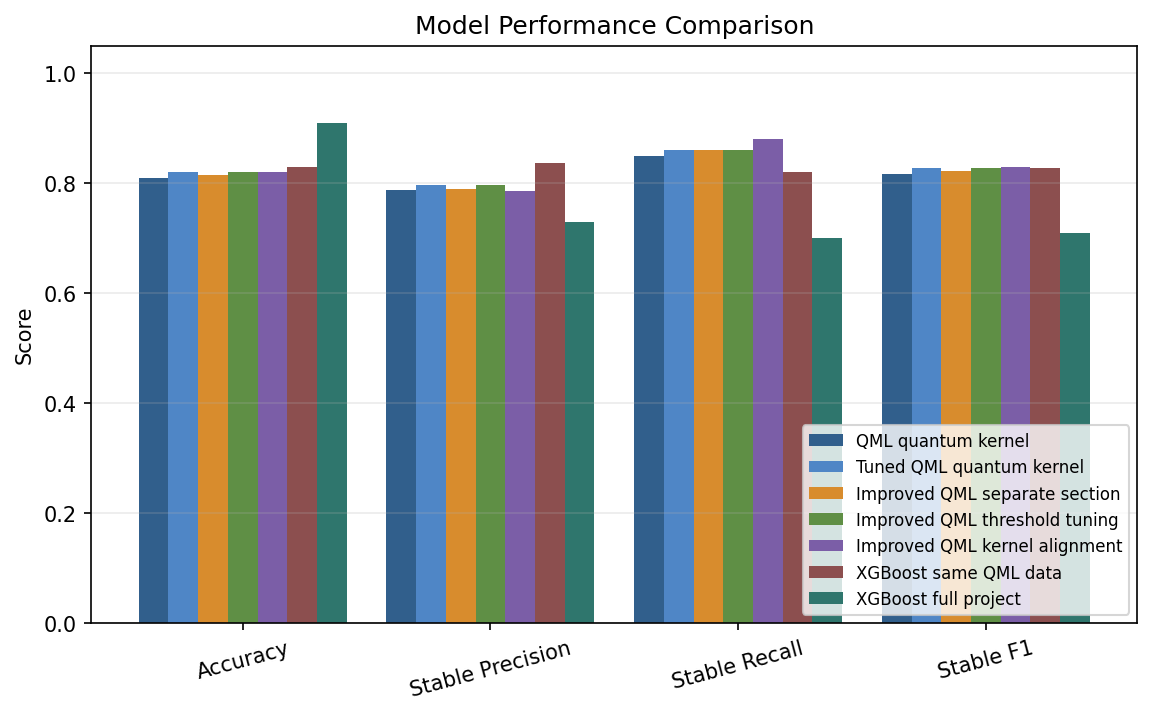

In [11]:
true_labels = qml_predictions_dataframe["target_is_stable"]
qml_predicted_labels = qml_predictions_dataframe["qml_predicted_label"]
xgboost_predicted_labels = qml_predictions_dataframe["xgboost_same_data_predicted_label"]
tuned_true_labels = tuned_qml_predictions_dataframe["target_is_stable"]
tuned_qml_predicted_labels = tuned_qml_predictions_dataframe["tuned_qml_predicted_label"]
improved_true_labels = improved_qml_predictions_dataframe["target_is_stable"]
improved_qml_predicted_labels = improved_qml_predictions_dataframe["improved_qml_predicted_label"]
threshold_true_labels = improved_qml_threshold_predictions_dataframe["target_is_stable"]
threshold_qml_predicted_labels = improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]
alignment_true_labels = improved_qml_alignment_predictions_dataframe["target_is_stable"]
alignment_qml_predicted_labels = improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]

metric_dataframe = pd.DataFrame([
    {
        "model": "QML quantum kernel",
        "accuracy": accuracy_score(true_labels, qml_predicted_labels),
        "stable_precision": precision_score(true_labels, qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(true_labels, qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(true_labels, qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Tuned QML quantum kernel",
        "accuracy": accuracy_score(tuned_true_labels, tuned_qml_predicted_labels),
        "stable_precision": precision_score(tuned_true_labels, tuned_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(tuned_true_labels, tuned_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(tuned_true_labels, tuned_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Improved QML separate section",
        "accuracy": accuracy_score(improved_true_labels, improved_qml_predicted_labels),
        "stable_precision": precision_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Improved QML threshold tuning",
        "accuracy": accuracy_score(threshold_true_labels, threshold_qml_predicted_labels),
        "stable_precision": precision_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Improved QML kernel alignment",
        "accuracy": accuracy_score(alignment_true_labels, alignment_qml_predicted_labels),
        "stable_precision": precision_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "XGBoost same QML data",
        "accuracy": accuracy_score(true_labels, xgboost_predicted_labels),
        "stable_precision": precision_score(true_labels, xgboost_predicted_labels, zero_division=0),
        "stable_recall": recall_score(true_labels, xgboost_predicted_labels, zero_division=0),
        "stable_f1": f1_score(true_labels, xgboost_predicted_labels, zero_division=0),
    },
    {
        "model": "XGBoost full project",
        "accuracy": 0.9091,
        "stable_precision": 0.7300,
        "stable_recall": 0.7000,
        "stable_f1": 0.7100,
    },
]).round(4)

display(metric_dataframe)

metric_dataframe.set_index("model")[["accuracy", "stable_precision", "stable_recall", "stable_f1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.show()

predicted_unstable,predicted_stable
78,22
14,86


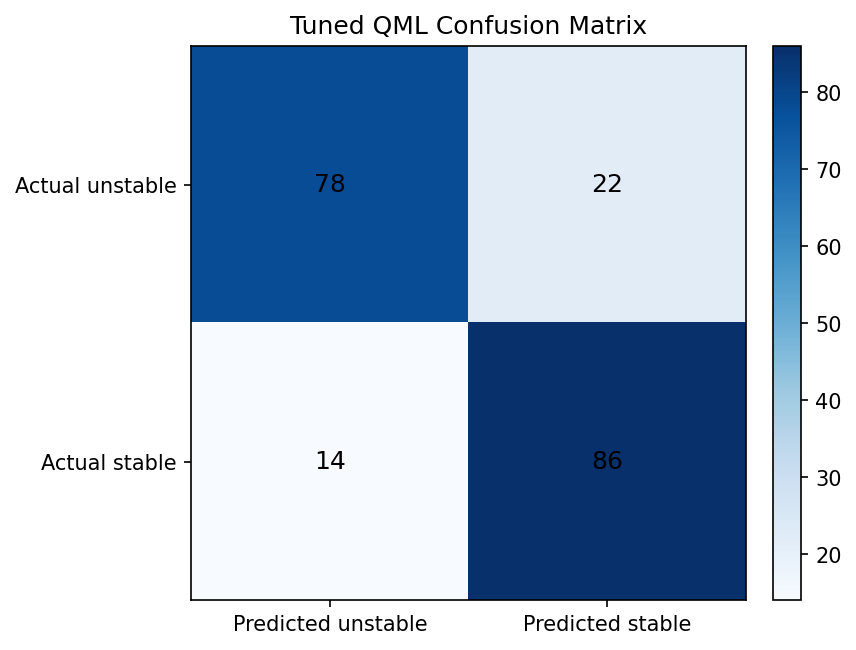

In [12]:
qml_confusion_matrix = confusion_matrix(tuned_true_labels, tuned_qml_predicted_labels, labels=[0, 1])
confusion_dataframe = pd.DataFrame(
    qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(qml_confusion_matrix, cmap="Blues")
plt.title("Tuned QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [13]:
sample_predictions_dataframe = tuned_qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "tuned_qml_predicted_label",
        "tuned_qml_stable_probability",
    ]
].head(10)
display(sample_predictions_dataframe)

material_id,formula,target_is_stable,tuned_qml_predicted_label,tuned_qml_stable_probability
mp-861915,LiDy2Ir,1,1,0.807657
mp-1191394,Li8Nd7Ge10,0,1,0.646342
mp-759724,Li3MnF7,0,0,0.224294
mp-37480,LiSbSe2,0,1,0.797944
mp-3203193,LiV(CuS2)2,1,1,0.879612
mp-3203521,BaSr2(LiSn2)4,1,1,0.648639
mp-1212343,Li22(Cu3Si2)7,1,1,0.846534
mp-1185354,LiGd2Os,1,1,0.838996
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.221231
mp-758945,Li5CuHO4,0,1,0.534829


In [14]:
improved_best_result = improved_qml_tuning_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "cv_stable_recall"],
    ascending=[False, False, False],
).iloc[0]

improved_true_labels = improved_qml_predictions_dataframe["target_is_stable"]
improved_qml_predicted_labels = improved_qml_predictions_dataframe["improved_qml_predicted_label"]

improved_summary_dataframe = pd.DataFrame([
    {
        "section": "Improved QML separate section",
        "feature_preparation": "feature importance + PCA",
        "best_kernel": improved_best_result["kernel_name"],
        "best_qubits": int(improved_best_result["pca_component_count"]),
        "angle_scale": improved_best_result["angle_scale"],
        "svm_c": improved_best_result["c_value"],
        "cv_stable_f1": improved_best_result["cv_stable_f1"],
        "test_accuracy": accuracy_score(improved_true_labels, improved_qml_predicted_labels),
        "test_stable_f1": f1_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
    }
]).round(4)

display(improved_summary_dataframe)

section,feature_preparation,best_kernel,best_qubits,angle_scale,svm_c,cv_stable_f1,test_accuracy,test_stable_f1
Improved QML separate section,feature importance + PCA,entangled_pi,6,pi,2.0,0.8596,0.815,0.823


predicted_unstable,predicted_stable
77,23
14,86


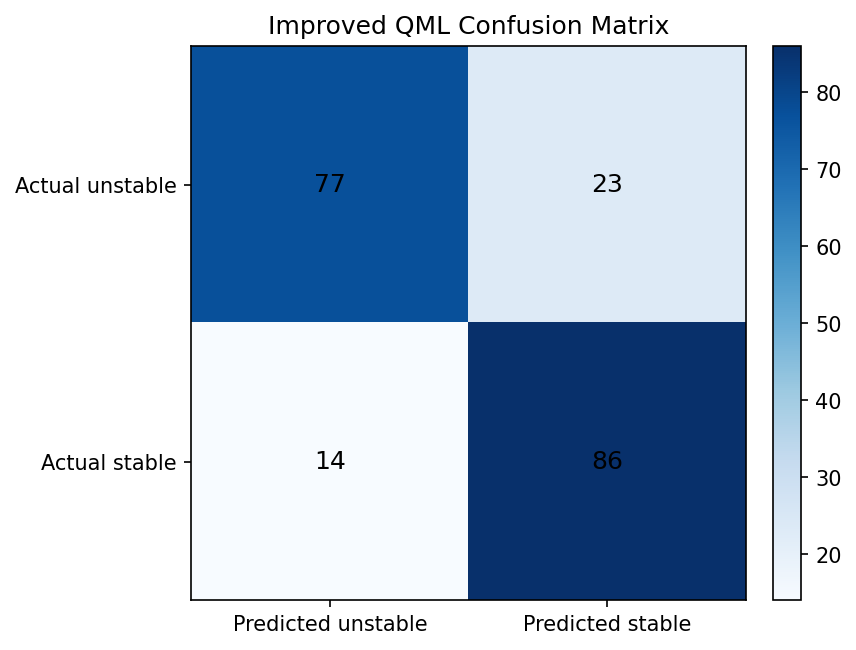

In [15]:
improved_qml_confusion_matrix = confusion_matrix(
    improved_true_labels,
    improved_qml_predicted_labels,
    labels=[0, 1],
)
improved_confusion_dataframe = pd.DataFrame(
    improved_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(improved_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(improved_qml_confusion_matrix, cmap="Blues")
plt.title("Improved QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, improved_qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [16]:
improved_sample_predictions_dataframe = improved_qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "improved_qml_predicted_label",
        "improved_qml_stable_probability",
    ]
].head(10)
display(improved_sample_predictions_dataframe)

material_id,formula,target_is_stable,improved_qml_predicted_label,improved_qml_stable_probability
mp-861915,LiDy2Ir,1,1,0.838005
mp-1191394,Li8Nd7Ge10,0,1,0.838534
mp-759724,Li3MnF7,0,1,0.711953
mp-37480,LiSbSe2,0,1,0.867497
mp-3203193,LiV(CuS2)2,1,1,0.861535
mp-3203521,BaSr2(LiSn2)4,1,1,0.840463
mp-1212343,Li22(Cu3Si2)7,1,1,0.869735
mp-1185354,LiGd2Os,1,1,0.837175
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.134662
mp-758945,Li5CuHO4,0,0,0.144349


In [17]:
improved_best_threshold_result = improved_qml_threshold_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "cv_stable_recall"],
    ascending=[False, False, False],
).iloc[0]

threshold_true_labels = improved_qml_threshold_predictions_dataframe["target_is_stable"]
threshold_qml_predicted_labels = improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]

threshold_summary_dataframe = pd.DataFrame([
    {
        "section": "Threshold experiment",
        "selected_threshold": improved_best_threshold_result["stable_threshold"],
        "cv_stable_f1": improved_best_threshold_result["cv_stable_f1"],
        "test_accuracy": accuracy_score(threshold_true_labels, threshold_qml_predicted_labels),
        "test_stable_precision": precision_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "test_stable_recall": recall_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "test_stable_f1": f1_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
    }
]).round(4)

display(threshold_summary_dataframe)

section,selected_threshold,cv_stable_f1,test_accuracy,test_stable_precision,test_stable_recall,test_stable_f1
Threshold experiment,0.5,0.8581,0.82,0.7963,0.86,0.8269


predicted_unstable,predicted_stable
78,22
14,86


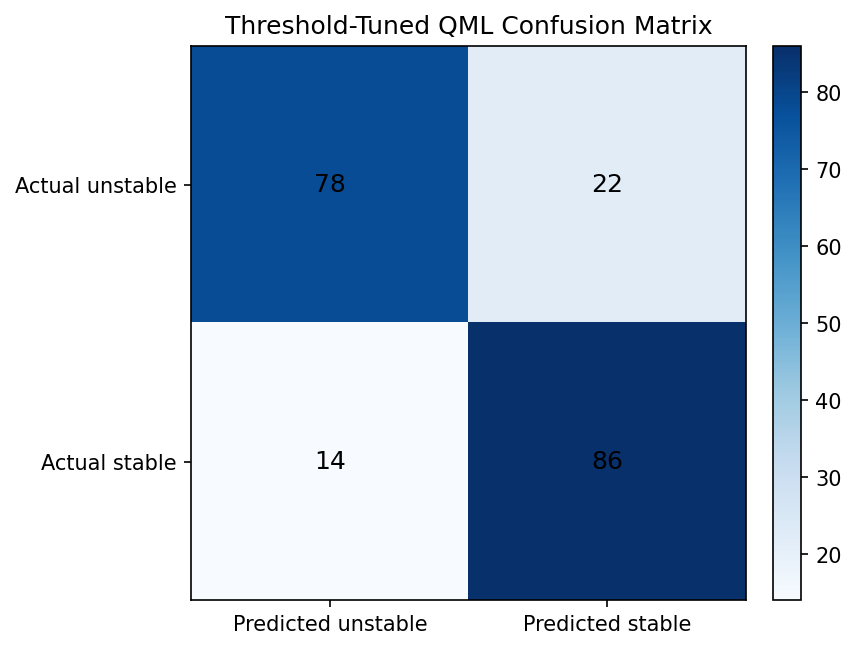

In [18]:
threshold_qml_confusion_matrix = confusion_matrix(
    threshold_true_labels,
    threshold_qml_predicted_labels,
    labels=[0, 1],
)
threshold_confusion_dataframe = pd.DataFrame(
    threshold_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(threshold_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(threshold_qml_confusion_matrix, cmap="Blues")
plt.title("Threshold-Tuned QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, threshold_qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [19]:
improved_best_alignment_result = improved_qml_alignment_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "kernel_target_alignment"],
    ascending=[False, False, False],
).iloc[0]

alignment_true_labels = improved_qml_alignment_predictions_dataframe["target_is_stable"]
alignment_qml_predicted_labels = improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]

alignment_summary_dataframe = pd.DataFrame([
    {
        "section": "Kernel alignment experiment",
        "feature_set": improved_best_alignment_result["feature_set_name"],
        "feature_count": int(improved_best_alignment_result["feature_count"]),
        "kernel": improved_best_alignment_result["kernel_name"],
        "angle_scale": improved_best_alignment_result["angle_scale"],
        "svm_c": improved_best_alignment_result["c_value"],
        "kernel_target_alignment": improved_best_alignment_result["kernel_target_alignment"],
        "cv_stable_f1": improved_best_alignment_result["cv_stable_f1"],
        "test_accuracy": accuracy_score(alignment_true_labels, alignment_qml_predicted_labels),
        "test_stable_f1": f1_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
    }
]).round(4)

display(alignment_summary_dataframe)

section,feature_set,feature_count,kernel,angle_scale,svm_c,kernel_target_alignment,cv_stable_f1,test_accuracy,test_stable_f1
Kernel alignment experiment,rf_top_4,4,entangled_pi,pi,5.0,0.378537,0.8568,0.82,0.8302


predicted_unstable,predicted_stable
76,24
12,88


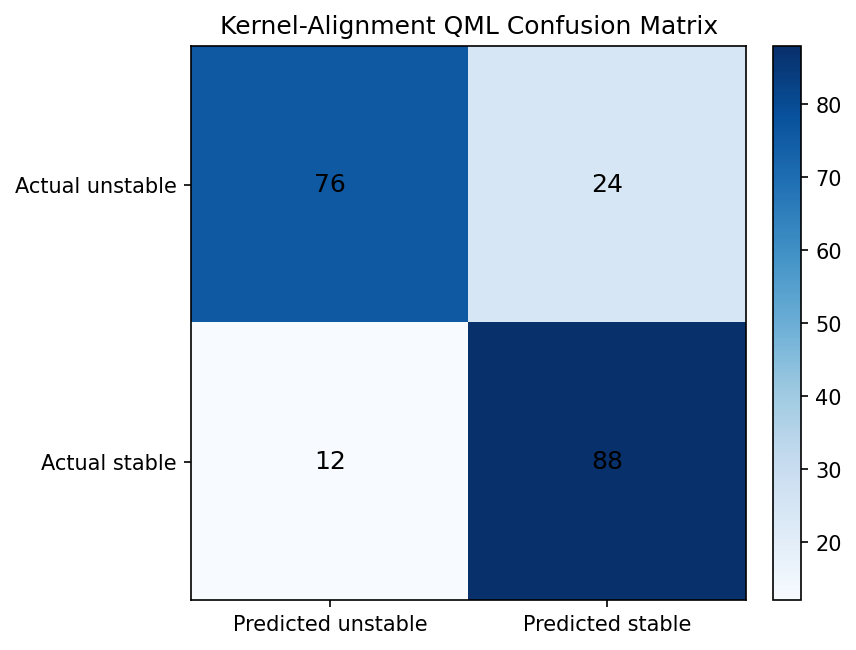

In [20]:
alignment_qml_confusion_matrix = confusion_matrix(
    alignment_true_labels,
    alignment_qml_predicted_labels,
    labels=[0, 1],
)
alignment_confusion_dataframe = pd.DataFrame(
    alignment_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(alignment_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(alignment_qml_confusion_matrix, cmap="Blues")
plt.title("Kernel-Alignment QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, alignment_qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [21]:
alignment_sample_predictions_dataframe = improved_qml_alignment_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "alignment_qml_predicted_label",
        "alignment_qml_stable_probability",
    ]
].head(10)
display(alignment_sample_predictions_dataframe)

material_id,formula,target_is_stable,alignment_qml_predicted_label,alignment_qml_stable_probability
mp-861915,LiDy2Ir,1,1,0.845221
mp-1191394,Li8Nd7Ge10,0,1,0.856232
mp-759724,Li3MnF7,0,1,0.704116
mp-37480,LiSbSe2,0,1,0.862706
mp-3203193,LiV(CuS2)2,1,1,0.873231
mp-3203521,BaSr2(LiSn2)4,1,1,0.861881
mp-1212343,Li22(Cu3Si2)7,1,1,0.823264
mp-1185354,LiGd2Os,1,1,0.838970
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.129983
mp-758945,Li5CuHO4,0,0,0.129832


In [22]:
repeated_split_summary_rows = []
repeated_split_metric_columns = [
    "accuracy",
    "stable_precision",
    "stable_recall",
    "stable_f1",
]

for metric_name in repeated_split_metric_columns:
    repeated_split_summary_rows.append(
        {
            "metric": metric_name,
            "mean": best_qml_repeated_split_results_dataframe[metric_name].mean(),
            "standard_deviation": best_qml_repeated_split_results_dataframe[metric_name].std(ddof=1),
            "minimum": best_qml_repeated_split_results_dataframe[metric_name].min(),
            "maximum": best_qml_repeated_split_results_dataframe[metric_name].max(),
        }
    )

repeated_split_summary_dataframe = pd.DataFrame(repeated_split_summary_rows).round(4)
display(repeated_split_summary_dataframe)

metric,mean,standard_deviation,minimum,maximum
accuracy,0.8550,0.0220,0.8150,0.8900
stable_precision,0.8389,0.0266,0.8053,0.8854
stable_recall,0.8800,0.0394,0.8200,0.9600
stable_f1,0.8583,0.0223,0.8159,0.8972


In [23]:
qml_vs_logistic_comparison_rows = []
metric_names = ["accuracy", "stable_precision", "stable_recall", "stable_f1"]

for metric_name in metric_names:
    qml_mean = qml_vs_logistic_summary_dataframe[
        (qml_vs_logistic_summary_dataframe["model"] == "QML kernel classifier")
        & (qml_vs_logistic_summary_dataframe["metric"] == metric_name)
    ]["mean"].iloc[0]
    logistic_mean = qml_vs_logistic_summary_dataframe[
        (qml_vs_logistic_summary_dataframe["model"] == "Logistic Regression")
        & (qml_vs_logistic_summary_dataframe["metric"] == metric_name)
    ]["mean"].iloc[0]
    difference = qml_mean - logistic_mean
    if difference > 0:
        winner = "QML"
    elif difference < 0:
        winner = "Logistic Regression"
    else:
        winner = "Tie"

    qml_vs_logistic_comparison_rows.append(
        {
            "metric": metric_name,
            "qml_mean": round(qml_mean, 4),
            "logistic_mean": round(logistic_mean, 4),
            "qml_minus_logistic": round(difference, 4),
            "winner": winner,
        }
    )

qml_vs_logistic_comparison_dataframe = pd.DataFrame(qml_vs_logistic_comparison_rows)
display(qml_vs_logistic_comparison_dataframe)

metric,qml_mean,logistic_mean,qml_minus_logistic,winner
accuracy,0.8550,0.8410,0.0140,QML
stable_precision,0.8389,0.8144,0.0245,QML
stable_recall,0.8800,0.8840,-0.0040,Logistic Regression
stable_f1,0.8583,0.8473,0.0110,QML


# Presentation Conclusion

**What we achieved**

- Built a complete lithium battery material pipeline.
- Created India-focused material scoring and final shortlist.
- Added QML-primary DSS recommendation rankings for exact compound formulas.
- Trained XGBoost as the strong present-day classical benchmark.
- Prepared a balanced QML-ready dataset.
- Trained a first simulated quantum-kernel classifier as the quantum-future
  experiment.
- Tuned QML hyperparameters using 4-fold cross-validation.
- Added exhaustive QML feature-combination tuning with 8,388 saved
  configurations.
- Added a separate improved-QML section using feature importance, PCA, and an
  entangled-kernel search.
- Added a threshold experiment for the improved-QML stable probability.
- Added a kernel-alignment experiment for quantum-aware feature selection.
- Validated the best QML setup across 10 random train/test splits.
- Compared best QML with Logistic Regression on the same repeated splits.
- Added a gate-level visual diagram for the best 4-qubit QML feature map.

**Main model result**

- XGBoost full-project accuracy: **0.9091**
- XGBoost regressor MAE: **0.1005**
- QML accuracy on QML-ready test split: **0.8100**
- Tuned QML accuracy on QML-ready test split: **0.8200**
- Tuned QML stable F1 on QML-ready test split: **0.8269**
- Improved QML separate-section accuracy: **0.8150**
- Improved QML separate-section stable F1: **0.8230**
- Improved QML threshold-tuned accuracy: **0.8200**
- Improved QML threshold-tuned stable F1: **0.8269**
- Improved QML kernel-alignment accuracy: **0.8200**
- Improved QML kernel-alignment stable F1: **0.8302**
- Repeated-split mean accuracy: **0.8550**
- Repeated-split mean stable F1: **0.8583**
- QML vs Logistic mean accuracy: **0.8550 vs 0.8410**
- QML vs Logistic mean stable F1: **0.8583 vs 0.8473**
- Same-data XGBoost accuracy: **0.8300**

**Safe interpretation**

XGBoost is stronger on the full tabular benchmark, but the final DSS is
quantum-led. QML gives the first recommendation signal and XGBoost is used as a
corrective backup when QML is uncertain or when the models disagree. The safe
student-level point is that quantum feature spaces are future-facing for
materials discovery, while classical ML can still act as a practical safety
check today.
